# Sprint 7 — Évaluation Fédérée Multicentrique & Optimisation Optuna

Ce notebook implémente le protocole expérimental du Sprint 7 pour EvoTrack-AI. Il compare trois scénarios d'entraînement sur des données longitudinales simulant un contexte multicentrique :

- apprentissage centralisé ;
- apprentissage fédéré standard avec FedAvg ;
- apprentissage fédéré avec FedBN, où les couches `BatchNormalization` restent locales.

Le protocole est académique et expérimental. Les métriques produites par ce notebook ne constituent pas une validation clinique et ne doivent pas être interprétées comme des performances diagnostiques réelles.

## 1. Imports

La stack est volontairement limitée à Python, TensorFlow/Keras, NumPy, Matplotlib, Optuna et quelques utilitaires standards.

In [22]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import optuna
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproductibilité
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## 2. Configuration globale

`FAST_DEV_RUN` permet de tester rapidement le notebook sur CPU. Pour lancer le protocole complet, passer cette variable à `False`.

In [23]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 4
COMMUNICATION_ROUNDS = 20
TEST_SIZE = 0.20
RANDOM_SEED = 42
FAST_DEV_RUN = False
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODEL_PATH = PROJECT_ROOT / "models" / "evotrack_siamese_best.keras"
USE_PRETRAINED_MODEL = not FAST_DEV_RUN

OPTUNA_TRIALS = 2 if FAST_DEV_RUN else 15
OPTUNA_ROUNDS = 1 if FAST_DEV_RUN else 5
BENCHMARK_ROUNDS = 2 if FAST_DEV_RUN else COMMUNICATION_ROUNDS
SYNTHETIC_SAMPLE_COUNT = 24 if FAST_DEV_RUN else 60

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print(f"FAST_DEV_RUN={FAST_DEV_RUN}")
print(f"Rounds benchmark utilises: {BENCHMARK_ROUNDS}/{COMMUNICATION_ROUNDS}")

FAST_DEV_RUN=False
Rounds benchmark utilises: 20/20


## 3. Chargement ou simulation des données

La fonction `load_real_pairs_if_available` est un point d'extension pour charger un dataset réel de paires `T0/T1`. Si aucune donnée réelle n'est disponible, le notebook génère un petit dataset synthétique de démonstration afin de rester exécutable de bout en bout.

Les données synthétiques ne sont pas des données cliniques et ne doivent pas être utilisées pour annoncer des résultats médicaux.

In [24]:
from pathlib import Path
import numpy as np
import tensorflow as tf


def load_real_pairs_if_available(
    base_dir=None,
    image_size=IMAGE_SIZE
):
    """
    Charge les vraies paires T0/T1 depuis outputs/tcia_preprocessed.

    Structure attendue :
    outputs/tcia_preprocessed/
        images_T0/
        images_T1/
        masks_T0/   optionnel, pas utilisé ici

    Retour :
        tuple (t0_images, t1_images, labels)
    ou None si les données ne sont pas disponibles localement.
    """

    if base_dir is None:
        base_dir = PROJECT_ROOT / "outputs" / "tcia_preprocessed"

    base_dir = Path(base_dir)
    t0_dir = base_dir / "images_T0"
    t1_dir = base_dir / "images_T1"

    if not t0_dir.exists() or not t1_dir.exists():
        print("Dossier tcia_preprocessed non trouvé.")
        print("Chemin attendu :", base_dir.resolve())
        return None

    valid_ext = ["*.png", "*.jpg", "*.jpeg", "*.bmp", "*.tif", "*.tiff", "*.npy"]

    t0_files = []
    t1_files = []

    for ext in valid_ext:
        t0_files.extend(t0_dir.glob(ext))
        t1_files.extend(t1_dir.glob(ext))

    t0_files = sorted(t0_files)
    t1_files = sorted(t1_files)

    if len(t0_files) == 0 or len(t1_files) == 0:
        print("Aucune image trouvée dans images_T0 ou images_T1.")
        return None

    n = min(len(t0_files), len(t1_files))

    if len(t0_files) != len(t1_files):
        print("Attention : nombre différent de fichiers T0 et T1.")
        print("T0 :", len(t0_files))
        print("T1 :", len(t1_files))
        print("Utilisation des", n, "premières paires.")

    t0_files = t0_files[:n]
    t1_files = t1_files[:n]

    t0_images = []
    t1_images = []

    for f0, f1 in zip(t0_files, t1_files):

        if f0.suffix.lower() == ".npy":
            arr0 = np.load(f0).astype(np.float32)
        else:
            img0 = tf.keras.utils.load_img(
                f0,
                color_mode="grayscale",
                target_size=image_size
            )
            arr0 = tf.keras.utils.img_to_array(img0).astype(np.float32)

        if f1.suffix.lower() == ".npy":
            arr1 = np.load(f1).astype(np.float32)
        else:
            img1 = tf.keras.utils.load_img(
                f1,
                color_mode="grayscale",
                target_size=image_size
            )
            arr1 = tf.keras.utils.img_to_array(img1).astype(np.float32)

        if arr0.ndim == 2:
            arr0 = np.expand_dims(arr0, axis=-1)

        if arr1.ndim == 2:
            arr1 = np.expand_dims(arr1, axis=-1)

        arr0 = tf.image.resize(arr0, image_size).numpy()
        arr1 = tf.image.resize(arr1, image_size).numpy()

        arr0 = np.clip(arr0, 0, 255)
        arr1 = np.clip(arr1, 0, 255)

        t0_images.append(arr0)
        t1_images.append(arr1)

    t0_images = np.array(t0_images, dtype=np.uint8)
    t1_images = np.array(t1_images, dtype=np.uint8)

    # Labels temporaires équilibrés pour permettre le calcul de l'AUC.
    # À remplacer plus tard par de vrais labels cliniques si disponibles.
    labels = np.zeros((n,), dtype=np.float32)
    labels[1::2] = 1.0

    print("Dataset réel détecté et chargé.")
    print("Chemin :", base_dir.resolve())
    print("Nombre de paires :", n)
    print("T0 shape :", t0_images.shape)
    print("T1 shape :", t1_images.shape)
    print("Labels shape :", labels.shape)

    return t0_images, t1_images, labels


def generate_synthetic_pairs(n_samples=48, image_shape=None, seed=42):
    """Genere un petit dataset synthetique binaire pour demonstration."""

    if image_shape is None:
        image_shape = (*IMAGE_SIZE, 1)

    rng = np.random.default_rng(seed)
    t0 = rng.normal(loc=80.0, scale=12.0, size=(n_samples, *image_shape)).astype(np.float32)
    t1 = t0.copy()
    labels = np.zeros((n_samples,), dtype=np.float32)

    yy, xx = np.ogrid[:image_shape[0], :image_shape[1]]

    for i in range(n_samples):
        if i % 2 == 1:
            labels[i] = 1.0
            cy = rng.integers(24, image_shape[0] - 24)
            cx = rng.integers(24, image_shape[1] - 24)
            radius = rng.integers(7, 13)
            mask = ((yy - cy) ** 2 + (xx - cx) ** 2) <= radius ** 2
            t1[i, mask, 0] += rng.uniform(45.0, 70.0)
        else:
            t1[i] += rng.normal(loc=0.0, scale=2.0, size=image_shape)

    t0 = np.clip(t0, 0, 255).astype(np.uint8)
    t1 = np.clip(t1, 0, 255).astype(np.uint8)

    return t0, t1, labels


loaded = load_real_pairs_if_available()

if loaded is None:
    print("Aucun dataset reel detecte : utilisation du fallback synthetique.")
    t0_images, t1_images, labels = generate_synthetic_pairs(
        n_samples=SYNTHETIC_SAMPLE_COUNT,
        seed=RANDOM_SEED,
    )
else:
    t0_images, t1_images, labels = loaded

print(t0_images.shape, t1_images.shape, labels.shape)
print("Distribution labels:", np.bincount(labels.astype(int)))

Dataset réel détecté et chargé.
Chemin : C:\projet_CV\EvoTrack-AI\outputs\tcia_preprocessed
Nombre de paires : 41
T0 shape : (41, 224, 224, 1)
T1 shape : (41, 224, 224, 1)
Labels shape : (41,)
(41, 224, 224, 1) (41, 224, 224, 1) (41,)
Distribution labels: [21 20]


## 4. Partitionnement Non-IID et prétraitement

Le test global contient 20 % des données. Les données restantes sont réparties entre trois hôpitaux virtuels :

- hôpital A : pipeline standard ;
- hôpital B : biais gain/offset `I' = clip(1.2 * I + 15, 0, 255)` ;
- hôpital C : bruit gaussien avec `sigma = 5`.

Toutes les images sont ensuite redimensionnées en `224 x 224` et normalisées dans `[-1, 1]`.

In [25]:
def stratified_train_test_split(labels, test_size=0.20, seed=42):
    """
    Sépare les données en train/test en conservant la proportion des classes.
    """
    rng = np.random.default_rng(seed)
    train_indices = []
    test_indices = []

    for class_value in np.unique(labels):
        class_indices = np.where(labels == class_value)[0]
        rng.shuffle(class_indices)

        n_test = max(1, int(round(len(class_indices) * test_size)))

        test_indices.extend(class_indices[:n_test])
        train_indices.extend(class_indices[n_test:])

    train_indices = np.array(train_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return train_indices, test_indices


def split_three_hospitals_stratified(indices, labels, seed=42):
    """
    Répartit les indices train en 3 hôpitaux virtuels A/B/C
    en gardant autant que possible une distribution équilibrée des classes.
    """
    rng = np.random.default_rng(seed)

    hospitals = [[], [], []]

    for class_value in np.unique(labels[indices]):
        class_indices = indices[labels[indices] == class_value]
        rng.shuffle(class_indices)

        parts = np.array_split(class_indices, 3)

        for i in range(3):
            hospitals[i].extend(parts[i])

    idx_A = np.array(hospitals[0])
    idx_B = np.array(hospitals[1])
    idx_C = np.array(hospitals[2])

    rng.shuffle(idx_A)
    rng.shuffle(idx_B)
    rng.shuffle(idx_C)

    return idx_A, idx_B, idx_C


def apply_domain_shift(t0, t1, hospital, seed=42):
    """
    Applique un biais artificiel différent selon l'hôpital.

    Hôpital A : aucun changement.
    Hôpital B : gain/offset d'intensité.
    Hôpital C : bruit gaussien.
    """
    t0 = t0.astype(np.float32)
    t1 = t1.astype(np.float32)

    if hospital == "B":
        t0 = np.clip(1.2 * t0 + 15.0, 0, 255)
        t1 = np.clip(1.2 * t1 + 15.0, 0, 255)

    elif hospital == "C":
        rng = np.random.default_rng(seed)
        t0 = np.clip(t0 + rng.normal(0.0, 5.0, size=t0.shape), 0, 255)
        t1 = np.clip(t1 + rng.normal(0.0, 5.0, size=t1.shape), 0, 255)

    return t0.astype(np.float32), t1.astype(np.float32)


def ensure_three_channels(array):
    """
    Convertit les images grayscale 1 canal en images 3 canaux
    pour être compatibles avec MobileNetV2.
    """
    if array.shape[-1] == 1:
        return np.repeat(array, repeats=3, axis=-1)

    return array


@tf.autograph.experimental.do_not_convert
def preprocess_pair(t0, t1, label):
    """
    Resize + normalisation [-1, 1].
    Retourne ((image_T0, image_T1), label)
    pour un modèle siamois à deux entrées.
    """
    t0 = tf.image.resize(t0, IMAGE_SIZE)
    t1 = tf.image.resize(t1, IMAGE_SIZE)

    t0 = (tf.cast(t0, tf.float32) / 127.5) - 1.0
    t1 = (tf.cast(t1, tf.float32) / 127.5) - 1.0

    return (t0, t1), tf.cast(label, tf.float32)


def make_dataset(t0, t1, y, hospital="A", shuffle=True, seed=42):
    """
    Crée un tf.data.Dataset pour un hôpital donné.
    """
    shifted_t0, shifted_t1 = apply_domain_shift(
        t0,
        t1,
        hospital=hospital,
        seed=seed
    )

    shifted_t0 = ensure_three_channels(shifted_t0)
    shifted_t1 = ensure_three_channels(shifted_t1)

    ds = tf.data.Dataset.from_tensor_slices(
        (shifted_t0, shifted_t1, y.astype(np.float32))
    )

    if shuffle:
        ds = ds.shuffle(
            buffer_size=len(y),
            seed=seed,
            reshuffle_each_iteration=True
        )

    ds = ds.map(preprocess_pair, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

    return ds


train_idx, test_idx = stratified_train_test_split(
    labels,
    test_size=TEST_SIZE,
    seed=RANDOM_SEED
)

idx_A, idx_B, idx_C = split_three_hospitals_stratified(
    train_idx,
    labels,
    seed=RANDOM_SEED
)

ds_A = make_dataset(
    t0_images[idx_A],
    t1_images[idx_A],
    labels[idx_A],
    hospital="A",
    seed=RANDOM_SEED
)

ds_B = make_dataset(
    t0_images[idx_B],
    t1_images[idx_B],
    labels[idx_B],
    hospital="B",
    seed=RANDOM_SEED + 1
)

ds_C = make_dataset(
    t0_images[idx_C],
    t1_images[idx_C],
    labels[idx_C],
    hospital="C",
    seed=RANDOM_SEED + 2
)

test_ds = make_dataset(
    t0_images[test_idx],
    t1_images[test_idx],
    labels[test_idx],
    hospital="A",
    shuffle=False,
    seed=RANDOM_SEED
)

print(f"Train A/B/C: {len(idx_A)}, {len(idx_B)}, {len(idx_C)} | Test: {len(test_idx)}")
print("Labels A:", np.bincount(labels[idx_A].astype(int)))
print("Labels B:", np.bincount(labels[idx_B].astype(int)))
print("Labels C:", np.bincount(labels[idx_C].astype(int)))
print("Labels Test:", np.bincount(labels[test_idx].astype(int)))

Train A/B/C: 12, 11, 10 | Test: 8
Labels A: [6 6]
Labels B: [6 5]
Labels C: [5 5]
Labels Test: [4 4]


### Visualisation rapide du domain shift

Cette cellule montre qualitativement l'effet des transformations simulées. Elle ne constitue pas une preuve clinique.

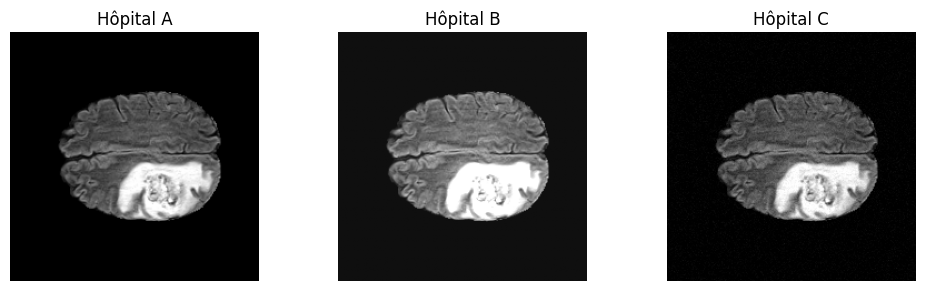

In [26]:
def show_hospital_examples():
    sample = t0_images[:1]
    paired = t1_images[:1]

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))

    for ax, hospital in zip(axes, ["A", "B", "C"]):
        shifted, _ = apply_domain_shift(
            sample,
            paired,
            hospital=hospital,
            seed=RANDOM_SEED
        )

        ax.imshow(shifted[0, :, :, 0], cmap="gray", vmin=0, vmax=255)
        ax.set_title(f"Hôpital {hospital}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_hospital_examples()

## 5. Modèle siamois

Le notebook tente de charger le modèle pré-entraîné `models/evotrack_siamese_best.keras`. Si ce chargement n'est pas possible, un petit modèle siamois minimal est créé afin de conserver un notebook exécutable sans dépendance au modèle métier.

In [31]:
@tf.keras.utils.register_keras_serializable(package="evotrack", name="absolute_difference")
def absolute_difference(tensors):
    """
    Fonction personnalisée utilisée par le modèle sauvegardé.
    Elle calcule la différence absolue entre les features T0 et T1.
    """
    return tf.abs(tensors[0] - tensors[1])


def build_fallback_siamese_model(input_shape=(224, 224, 3)):
    """
    Petit modèle siamois fallback.
    Il est utilisé si le vrai modèle pré-entraîné ne peut pas être chargé.
    """

    input_t0 = keras.Input(shape=input_shape, name="t0")
    input_t1 = keras.Input(shape=input_shape, name="t1")

    conv1 = layers.Conv2D(
        8,
        3,
        padding="same",
        activation="relu",
        name="shared_conv_1"
    )

    bn1 = layers.BatchNormalization(
        name="batch_normalization_fallback_1"
    )

    pool1 = layers.MaxPooling2D(
        name="shared_pool_1"
    )

    conv2 = layers.Conv2D(
        16,
        3,
        padding="same",
        activation="relu",
        name="shared_conv_2"
    )

    bn2 = layers.BatchNormalization(
        name="batch_normalization_fallback_2"
    )

    gap = layers.GlobalAveragePooling2D(
        name="shared_gap"
    )

    def encode(inputs):
        x = conv1(inputs)
        x = bn1(x)
        x = pool1(x)
        x = conv2(x)
        x = bn2(x)
        x = gap(x)
        return x

    features_t0 = encode(input_t0)
    features_t1 = encode(input_t1)

    diff = layers.Lambda(
        absolute_difference,
        output_shape=lambda shapes: shapes[0],
        name="absolute_difference"
    )([features_t0, features_t1])

    x = layers.Dense(
        16,
        activation="relu",
        name="dense_fallback"
    )(diff)

    output = layers.Dense(
        1,
        activation="sigmoid",
        name="evolution_probability"
    )(x)

    model = keras.Model(
        inputs=[input_t0, input_t1],
        outputs=output,
        name="fallback_siamese"
    )

    return model


def make_base_model():
    """
    Charge le modèle pré-entraîné si possible.
    Sinon, utilise le modèle fallback.
    """

    if USE_PRETRAINED_MODEL and MODEL_PATH.exists():
        try:
            print(f"Chargement du modele existant : {MODEL_PATH}")

            model = keras.models.load_model(
                MODEL_PATH,
                compile=False,
                safe_mode=False,
                custom_objects={
                    "absolute_difference": absolute_difference
                }
            )

            print("Modèle pré-entraîné chargé avec succès.")
            return model

        except Exception as exc:
            print("Chargement impossible.")
            print("Erreur :", exc)
            print("Utilisation du modele fallback.")

    elif not MODEL_PATH.exists():
        print(f"Modele absent : {MODEL_PATH}. Utilisation du modele fallback.")

    else:
        print("FAST_DEV_RUN actif : utilisation du modele fallback pour accelerer le test.")

    return build_fallback_siamese_model(input_shape=(*IMAGE_SIZE, 3))


def clone_uncompiled_model(model):
    """
    Clone un modèle sans compilation.
    Nécessaire pour créer les modèles locaux A/B/C et le modèle global.
    """

    if model.name == "fallback_siamese":
        cloned = build_fallback_siamese_model(input_shape=(*IMAGE_SIZE, 3))
    else:
        cloned = keras.models.clone_model(model)

    cloned.set_weights(model.get_weights())

    return cloned


def compile_model(model, lr):
    """
    Compile le modèle avec Adam, binary_crossentropy, accuracy et AUC.
    """

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.AUC(name="auc")
        ]
    )

    return model


base_model = make_base_model()
base_model.summary()

Chargement du modele existant : c:\projet_CV\EvoTrack-AI\models\evotrack_siamese_best.keras
Modèle pré-entraîné chargé avec succès.


Model: "evotrack_siamese_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_t0            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_t1            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ image_t0[0][0],   │
│ (Functional)        │ 1280)             │            │ image_t1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ absolute_difference │ (None, 7, 7,      │          0 │ mobilenetv2_1.00… │
│ (Lambda)            │ 1280)             │            │ mobilenetv2_1.00… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ absolute_differe… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_128 (Dense)   │ (None, 128)       │    163,968 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense_128[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ prediction (Dense)  │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 6. Fonctions d'agrégation

FedAvg moyenne tous les poids des couches compatibles. FedBN applique la même logique sauf pour les couches `BatchNormalization`, qui restent locales et ne sont pas écrasées.

In [32]:
def iter_leaf_layers(model, prefix=""):
    """Parcourt recursivement les couches portant effectivement des poids."""
    for layer in model.layers:
        layer_path = f"{prefix}/{layer.name}" if prefix else layer.name
        if isinstance(layer, keras.Model):
            yield from iter_leaf_layers(layer, prefix=layer_path)
        elif layer.weights:
            yield layer_path, layer


def get_trainable_weights_dict(model):
    """Retourne les poids entrainables par chemin de couche."""
    return {
        layer_path: [weight.numpy() for weight in layer.trainable_weights]
        for layer_path, layer in iter_leaf_layers(model)
        if layer.trainable_weights
    }


def is_batch_norm_layer(layer):
    return isinstance(layer, layers.BatchNormalization) or "batch_normalization" in layer.name.lower()


def aggregate_fedavg(global_model, list_local_models):
    """Moyenne arithmetique des poids et synchronisation globale/locale."""
    global_layers = list(iter_leaf_layers(global_model))
    local_layers_by_model = [list(iter_leaf_layers(model)) for model in list_local_models]
    for layer_index, (_, global_layer) in enumerate(global_layers):
        local_layers = [layers_for_model[layer_index][1] for layers_for_model in local_layers_by_model]
        local_weights = [layer.get_weights() for layer in local_layers]
        if not local_weights or not local_weights[0]:
            continue
        averaged_weights = [
            np.mean([weights[i] for weights in local_weights], axis=0)
            for i in range(len(local_weights[0]))
        ]
        global_layer.set_weights(averaged_weights)
        for local_layer in local_layers:
            local_layer.set_weights(averaged_weights)
    return global_model, list_local_models


def aggregate_fedbn(global_model, list_local_models):
    """FedBN : moyenne les couches non-BN et preserve les BatchNorm locales."""
    global_layers = list(iter_leaf_layers(global_model))
    local_layers_by_model = [list(iter_leaf_layers(model)) for model in list_local_models]
    for layer_index, (_, global_layer) in enumerate(global_layers):
        local_layers = [layers_for_model[layer_index][1] for layers_for_model in local_layers_by_model]
        if is_batch_norm_layer(global_layer):
            continue
        local_weights = [layer.get_weights() for layer in local_layers]
        if not local_weights or not local_weights[0]:
            continue
        averaged_weights = [
            np.mean([weights[i] for weights in local_weights], axis=0)
            for i in range(len(local_weights[0]))
        ]
        global_layer.set_weights(averaged_weights)
        for local_layer in local_layers:
            local_layer.set_weights(averaged_weights)
    return global_model, list_local_models


sample_weights = get_trainable_weights_dict(base_model)
print(f"Couches avec poids entrainables: {len(sample_weights)}")

Couches avec poids entrainables: 2


## 7. Recherche d'hyperparamètres avec Optuna

L'objectif Optuna exécute une mini-boucle FedAvg et retourne l'AUC de validation sur `test_ds`. En mode développement rapide, le nombre d'essais et de rounds est volontairement réduit.

In [33]:
def evaluate_auc(model, dataset):
    results = model.evaluate(dataset, verbose=0, return_dict=True)
    return float(results.get("auc", 0.0)), float(results.get("loss", np.nan))


def make_federated_models(lr):
    global_model = compile_model(clone_uncompiled_model(base_model), lr)
    local_models = [compile_model(clone_uncompiled_model(base_model), lr) for _ in range(3)]
    return global_model, local_models


def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 5e-4, log=True)
    local_epochs = trial.suggest_categorical("local_epochs", [1, 2, 3])
    global_model, local_models = make_federated_models(lr)
    local_datasets = [ds_A, ds_B, ds_C]

    for _ in range(OPTUNA_ROUNDS):
        for model, dataset in zip(local_models, local_datasets):
            model.fit(dataset, epochs=local_epochs, verbose=0)
        global_model, local_models = aggregate_fedavg(global_model, local_models)

    auc, _ = evaluate_auc(global_model, test_ds)
    return auc


study = optuna.create_study(direction="maximize", study_name="evotrack_sprint7_fedavg")
study.optimize(objective, n_trials=OPTUNA_TRIALS)
best_params = study.best_params

print("Meilleurs hyperparametres Optuna:", best_params)

[I 2026-05-29 00:41:56,150] A new study created in memory with name: evotrack_sprint7_fedavg
[I 2026-05-29 00:42:36,487] Trial 0 finished with value: 0.8125 and parameters: {'lr': 6.387307131715524e-05, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 00:43:09,355] Trial 1 finished with value: 0.8125 and parameters: {'lr': 0.00037907703290825307, 'local_epochs': 2}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 00:43:47,713] Trial 2 finished with value: 0.6875 and parameters: {'lr': 1.0927708895647159e-05, 'local_epochs': 3}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 00:44:18,926] Trial 3 finished with value: 0.8125 and parameters: {'lr': 0.00013721327283123708, 'local_epochs': 1}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 00:44:47,059] Trial 4 finished with value: 0.8125 and parameters: {'lr': 8.344399809657438e-05, 'local_epochs': 1}. Best is trial 0 with value: 0.8125.
[I 2026-05-29 00:45:19,135] Trial 5 finished with value: 0.6875 and parame

Meilleurs hyperparametres Optuna: {'lr': 6.387307131715524e-05, 'local_epochs': 3}


## 8. Benchmark final

Les trois scénarios sont entraînés avec les meilleurs hyperparamètres issus d'Optuna. Les historiques stockent la Loss et l'AUC de validation. En version complète, le benchmark utilise `COMMUNICATION_ROUNDS = 20`.

In [34]:
def concatenate_datasets(datasets):
    ds = datasets[0]
    for next_ds in datasets[1:]:
        ds = ds.concatenate(next_ds)
    return ds


def benchmark_centralized(lr, local_epochs, rounds):
    model = compile_model(clone_uncompiled_model(base_model), lr)
    ds_global = concatenate_datasets([ds_A, ds_B, ds_C])
    history = {"loss": [], "auc": []}
    for _ in range(rounds):
        model.fit(ds_global, epochs=local_epochs, verbose=0)
        auc, loss = evaluate_auc(model, test_ds)
        history["loss"].append(loss)
        history["auc"].append(auc)
    return history


def benchmark_federated(lr, local_epochs, rounds, aggregation_fn):
    global_model, local_models = make_federated_models(lr)
    local_datasets = [ds_A, ds_B, ds_C]
    history = {"loss": [], "auc": []}
    for _ in range(rounds):
        for model, dataset in zip(local_models, local_datasets):
            model.fit(dataset, epochs=local_epochs, verbose=0)
        global_model, local_models = aggregation_fn(global_model, local_models)
        auc, loss = evaluate_auc(global_model, test_ds)
        history["loss"].append(loss)
        history["auc"].append(auc)
    return history


selected_lr = float(best_params.get("lr", 1e-4))
selected_local_epochs = int(best_params.get("local_epochs", 1))

centralized_history = benchmark_centralized(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS)
fedavg_history = benchmark_federated(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS, aggregate_fedavg)
fedbn_history = benchmark_federated(selected_lr, selected_local_epochs, BENCHMARK_ROUNDS, aggregate_fedbn)

print("Centralise:", centralized_history)
print("FedAvg:", fedavg_history)
print("FedBN:", fedbn_history)

Centralise: {'loss': [0.6526659727096558, 0.6687408685684204, 0.6464542746543884, 0.6410326957702637, 0.6460306644439697, 0.6282318830490112, 0.6277250051498413, 0.6203557848930359, 0.6048048138618469, 0.6073738932609558, 0.6124997735023499, 0.5994039177894592, 0.5985785722732544, 0.5947506427764893, 0.5911164283752441, 0.5896037817001343, 0.594103217124939, 0.585465133190155, 0.5811588764190674, 0.578168511390686], 'auc': [0.78125, 0.8125, 0.8125, 0.8125, 0.8125, 0.78125, 0.8125, 0.75, 0.8125, 0.75, 0.8125, 0.75, 0.75, 0.75, 0.75, 0.78125, 0.8125, 0.8125, 0.8125, 0.8125]}
FedAvg: {'loss': [0.6590906977653503, 0.6511751413345337, 0.6474472284317017, 0.6467471122741699, 0.6458741426467896, 0.6450043320655823, 0.6429846286773682, 0.641412615776062, 0.6385086178779602, 0.6346941590309143, 0.6310454607009888, 0.6262829899787903, 0.6237576007843018, 0.6226860880851746, 0.6220613121986389, 0.6216825842857361, 0.6209805607795715, 0.6182667016983032, 0.6149013638496399, 0.6157821416854858], 'a

## 9. Visualisation comparative

Le graphique ci-dessous compare l'AUC de validation des trois scénarios. Il doit être lu comme une comparaison expérimentale dans un cadre contrôlé, sans extrapolation clinique.

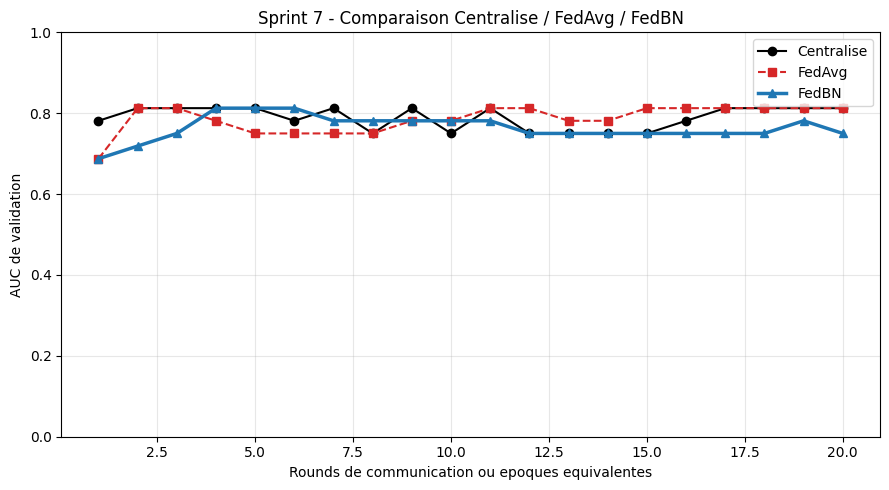

In [35]:
%matplotlib inline

round_axis = np.arange(1, BENCHMARK_ROUNDS + 1)

plt.figure(figsize=(9, 5))
plt.plot(round_axis, centralized_history["auc"], color="black", marker="o", label="Centralise")
plt.plot(round_axis, fedavg_history["auc"], color="tab:red", linestyle="--", marker="s", label="FedAvg")
plt.plot(round_axis, fedbn_history["auc"], color="tab:blue", linewidth=2.5, marker="^", label="FedBN")
plt.title("Sprint 7 - Comparaison Centralise / FedAvg / FedBN")
plt.xlabel("Rounds de communication ou epoques equivalentes")
plt.ylabel("AUC de validation")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Analyse méthodologique

Cette figure sert à comparer le comportement relatif des trois scénarios sous domain shift simulé. Une éventuelle différence entre FedAvg et FedBN doit être interprétée comme un résultat expérimental dépendant du dataset, du modèle, des transformations et des hyperparamètres utilisés.

Le notebook ne démontre pas une supériorité clinique de FedBN. Il fournit un protocole reproductible pour étudier si la conservation des statistiques Batch Normalization locales améliore la robustesse dans cette simulation multicentrique.

## 10. Conclusion

Ce notebook matérialise le protocole Sprint 7 : partitionnement Non-IID, agrégation Keras FedAvg/FedBN, optimisation Optuna et benchmark comparatif. Le fallback synthétique permet une exécution minimale même sans dataset réel.

Les résultats obtenus sont expérimentaux et académiques. Ils ne remplacent pas une validation clinique, ne constituent pas une preuve de performance diagnostique et ne doivent pas être utilisés pour une décision médicale.